## Ana CNN

In [1]:
%matplotlib inline 
#%matplotlib notebook
#matplotlib widget
%reload_ext autoreload
%autoreload 2

In [2]:
import random            as random
import numpy             as np
import pandas            as pd
#import tables            as tb
import matplotlib.pyplot as plt
import os 

In [3]:
import xyimg.dataprep as dp
import xyimg.cnn      as cnn
import xyimg.utils    as ut

In [13]:
ipath  = os.environ['LPRDATADIR']+'cnn/'

sfilenames = ['5bar_xy_segclass_max+yz_segclass_max+zx_segclass_max_w5_HCNN.npz',
             '13bar_xy_segclass_max+yz_segclass_max+zx_segclass_max_w5_HCNN.npz',
             '20bar_xy_segclass_max+yz_segclass_max+zx_segclass_max_w5_HCNN.npz']

slabels  =  ['5bar 5mm seg', '13bar 5mm seg', '20bar 5mm seg']
             
efilenames = ['5bar_xy_E_sum+yz_E_sum+zx_E_sum_w5_HCNN.npz',
              '13bar_xy_E_sum+yz_E_sum+zx_E_sum_w5_HCNN.npz',
              '20bar_xy_E_sum+yz_E_sum+zx_E_sum_w5_HCNN.npz',
              '13bar_xy_E_sum+yz_E_sum+zx_E_sum_w2_HCNN.npz',
              '13bar_xy_E_sum+yz_E_sum+zx_E_sum_w2_HCNN.npz']

elabels  =  ['5bar 5mm E', '13bar 5mm E', '20bar 5mm E', '13bar 2mm E', '20bar 2mm E']

## RoC esum widths

In [9]:
def ind_rocs(filenames, labels):
    for ifile, label in zip(filenames, labels):
        cres = np.load(ipath + ifile)
        cnn.plot_roc(cres['y'], cres['yp']); plt.title(label)
    return



In [10]:
def rocs(files, labels, title = '', rejection = 0.):
    ydir, ypdir  = {}, {}
    plt.figure()
    for ifile, label in zip(files, labels):
        cnndata      = np.load(ipath + ifile)
        ydir [label] = cnndata['y'] 
        ypdir[label] = cnndata['yp']
        y, yp  = ydir[label], ypdir[label]
        yr, ys = cnn.roc_vals(y, yp)
        #eff    = cnn.roc_value(y, yp, rejection)
        #print(f"{label} efficiency {eff} at {rejection} rejection")
        plt.plot(yr, ys, label = label, lw = 2, alpha = .8)
        plt.xlim((rejection, 1.))
        plt.legend()
    plt.grid()
    plt.xlabel('rejection'); plt.ylabel('efficiency');
    plt.title(title);
    sname   = ut.str_concatenate(('img/roc_', title), '_') + '.png'
    print('save figure at ', sname)
    plt.savefig(sname)

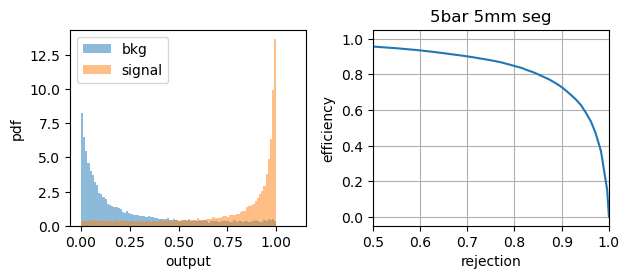

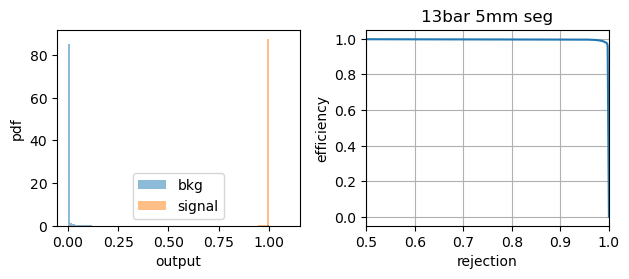

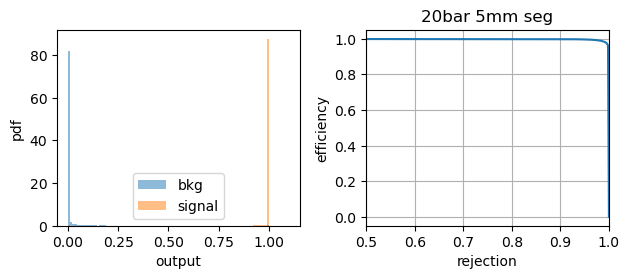

In [14]:
ind_rocs(sfilenames, slabels)

save figure at  img/roc__.png


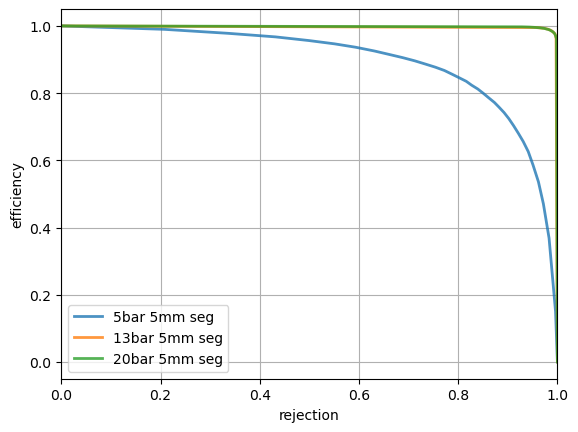

In [15]:
rocs(sfilenames, slabels)

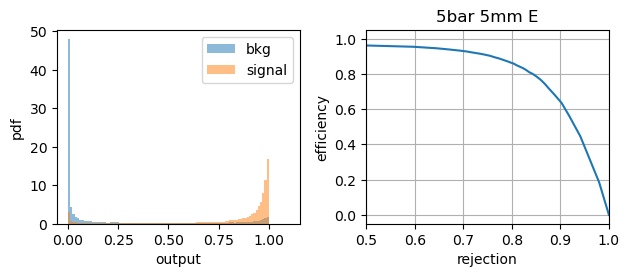

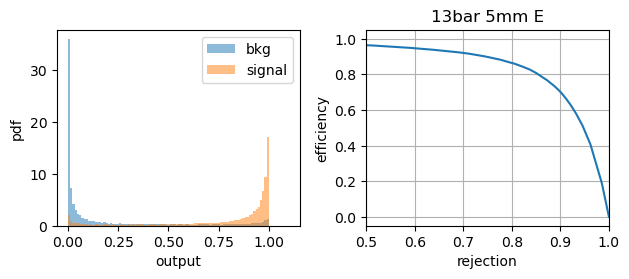

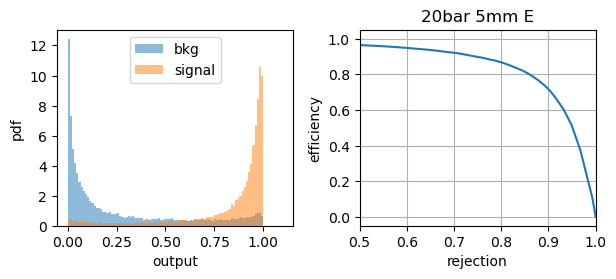

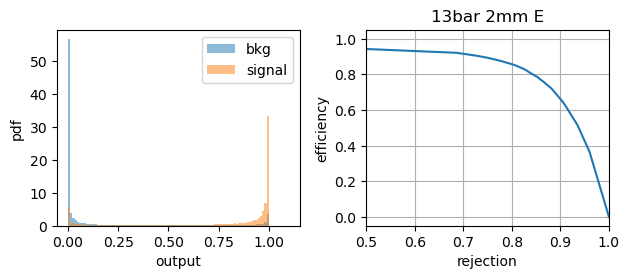

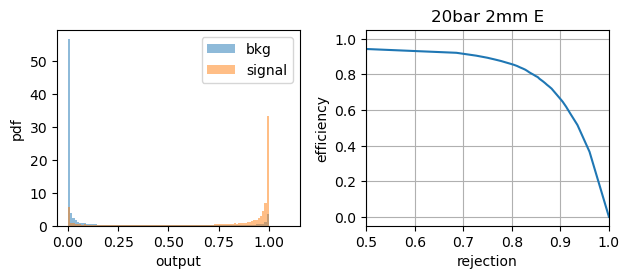

In [16]:
ind_rocs(efilenames, elabels)

save figure at  img/roc__.png


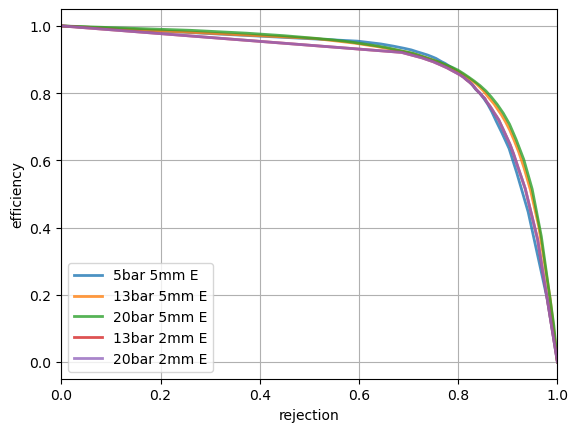

In [17]:
rocs(efilenames, elabels)

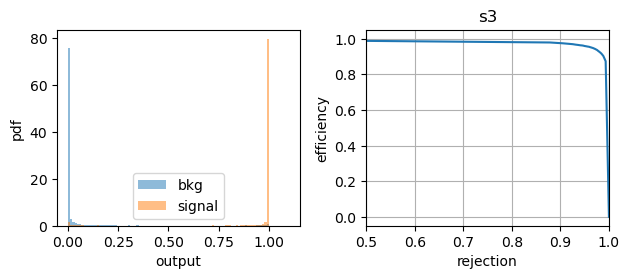

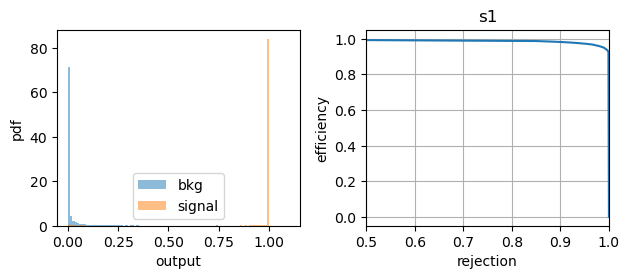

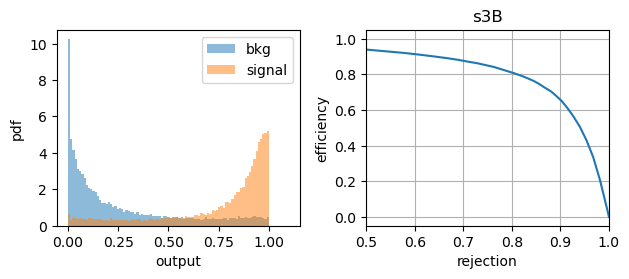

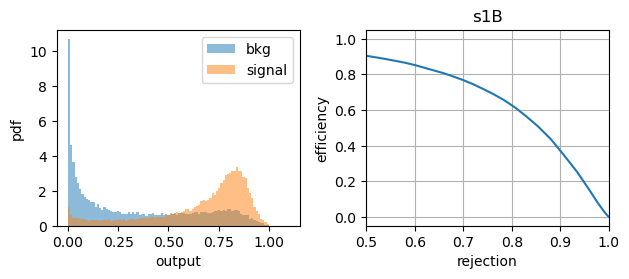

In [39]:
ind_rocs(sfilenames, slabels)

save figure at  img/roc__.png


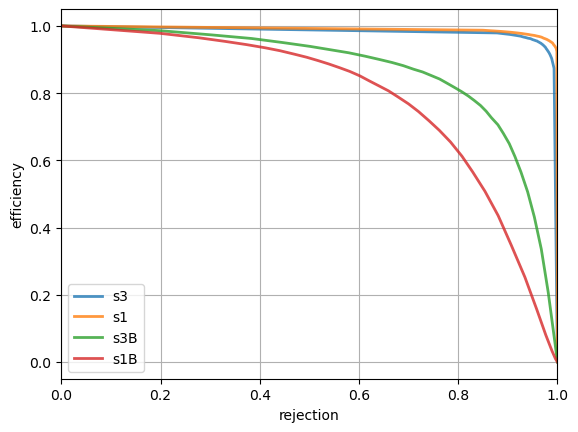

In [40]:
rocs(sfilenames, slabels)

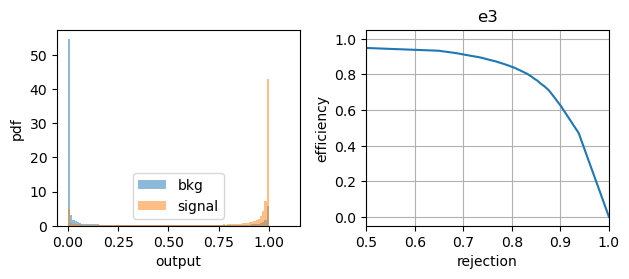

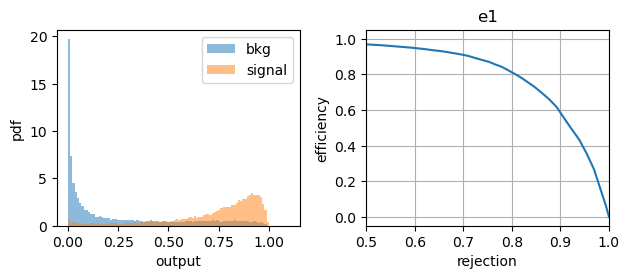

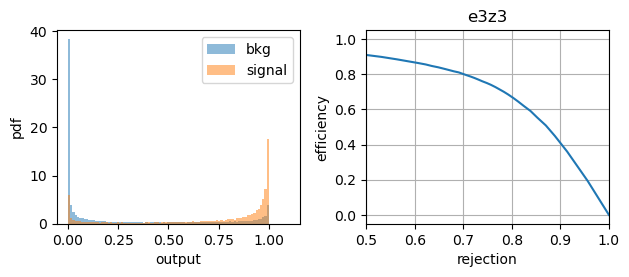

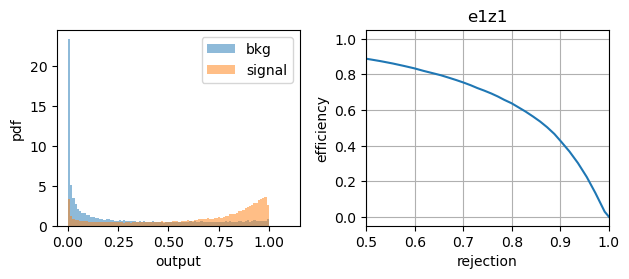

In [44]:
ind_rocs(zfilenames, zlabels)

save figure at  img/roc__.png


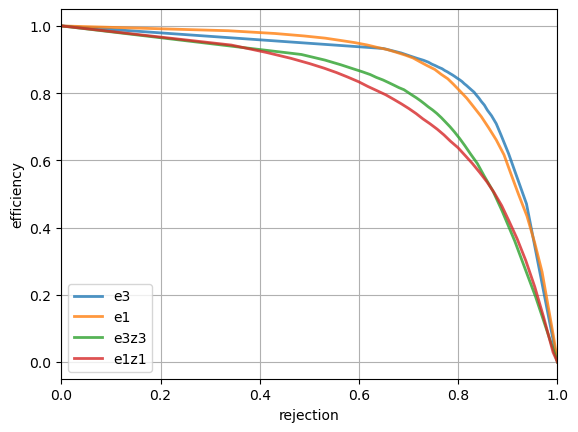

In [45]:
rocs(zfilenames, zlabels)

## RoC colors

In [36]:
def roc_colors(pressure, widths, colors, rejection = 0.9):
    ydir, ypdir  = {}, {}
    plt.figure()
    for labels in colors:
        _ , ifile   = cnn.get_cnn_filenames(pressure, projection, widths, labels)
        cnndata     = np.load(ipath + ifile)
        name        = dp.str_concatenate(labels, '+')
        ydir[name]  = cnndata['y'] .flatten()
        ypdir[name] = cnndata['yp'].flatten()
        yr, ys = cnn.roc_vals(ydir[name], ypdir[name])
        plt.plot(yr, ys, label = name, lw = 2)
        plt.xlim((rejection, 1.))
        plt.legend()
    plt.grid()
    plt.xlabel('rejection'); plt.ylabel('efficiency');
    plt.title(pressure);
    swidths = dp.str_concatenate(widths, 'x')
    sname   = dp.str_concatenate(('img/roc_colors_', pressure, swidths), '_') + '.png'
    print('save figure at ', sname)
    plt.savefig(sname)


save figure at  img/roc_colors__13bar_10x10.png


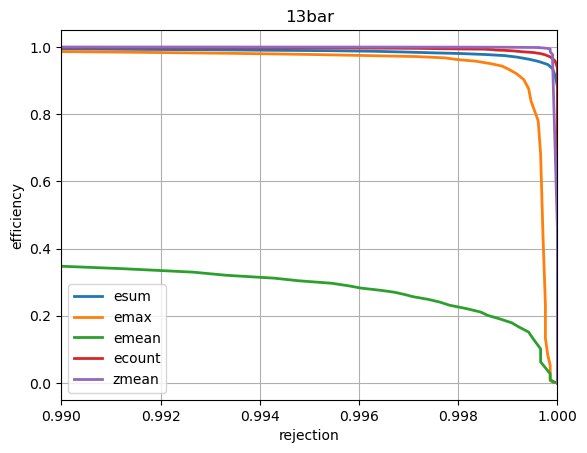

In [37]:
pressure = '13bar'
colors   = [['esum'], ['emax'], ['emean'], ['ecount'], ['zmean']]
widths   = (10, 10)
roc_colors(pressure, widths, colors, 0.99)

## Ana Test and Seg Images

In [53]:
def roc_test(pressures, widths, labels, rejection = 0.9):
    ydir, ypdir  = {}, {}
    plt.figure()
    for pressure in pressures:
        _ , ifile   = cnn.get_cnn_filenames(pressure, projection, widths, labels)
        cnndata     = np.load(ipath + ifile)
        name        = pressure
        ydir[name]  = cnndata['y'] .flatten()
        ypdir[name] = cnndata['yp'].flatten()
        yr, ys = cnn.roc_vals(ydir[name], ypdir[name])
        plt.plot(yr, ys, label = name, lw = 2, alpha = 0.8)
        plt.xlim((rejection, 1.))
        plt.legend()
    plt.grid()
    plt.xlabel('rejection'); plt.ylabel('efficiency');
    slabels = dp.str_concatenate(labels, '+')
    swidths = dp.str_concatenate(widths, 'x')
    title   = dp.str_concatenate((swidths, slabels), '_')
    plt.title(title);
    sname   = dp.str_concatenate(('img/roc_test_', title), '_') + '.png'
    print('save figure at ', sname)
    plt.savefig(sname)


save figure at  img/roc_test__10x10_seg.png


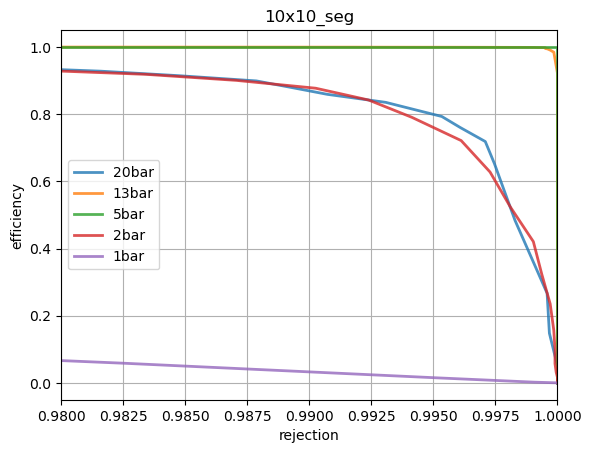

In [54]:
pressures = ('20bar', '13bar', '5bar', '2bar', '1bar')
widths    = (10, 10)
labels    = ['seg']
roc_test(pressures, widths, labels, 0.98)

save figure at  img/roc_test__10x10_test.png


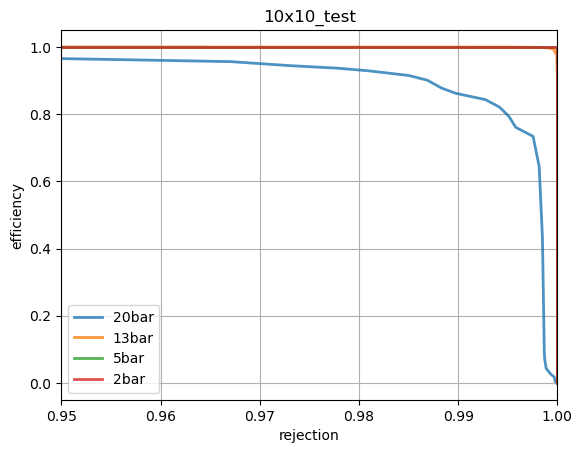

In [56]:
pressures = ('20bar', '13bar', '5bar', '2bar')
widths    = (10, 10)
labels    = ['test']
roc_test(pressures, widths, labels, 0.95)